### Import Libraries

In [489]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Cleaning

In [490]:
yield_data = pd.read_csv("KENYA_FAOSTAT_data_en_5-11-2026.csv")
yield_data.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,404,Kenya,5412,Yield,1701,"Beans, dry",1984,1984,kg/ha,612.2,E,Estimated value,NaN
1,QCL,Crops and livestock products,404,Kenya,5412,Yield,1701,"Beans, dry",1985,1985,kg/ha,612.2,E,Estimated value,NaN
2,QCL,Crops and livestock products,404,Kenya,5412,Yield,1701,"Beans, dry",1986,1986,kg/ha,615.4,E,Estimated value,NaN
3,QCL,Crops and livestock products,404,Kenya,5412,Yield,1701,"Beans, dry",1987,1987,kg/ha,636.4,E,Estimated value,NaN
4,QCL,Crops and livestock products,404,Kenya,5412,Yield,1701,"Beans, dry",1988,1988,kg/ha,655.2,E,Estimated value,NaN


In [491]:
yield_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       205 non-null    str    
 1   Domain            205 non-null    str    
 2   Area Code (M49)   205 non-null    int64  
 3   Area              205 non-null    str    
 4   Element Code      205 non-null    int64  
 5   Element           205 non-null    str    
 6   Item Code (CPC)   205 non-null    int64  
 7   Item              205 non-null    str    
 8   Year Code         205 non-null    int64  
 9   Year              205 non-null    int64  
 10  Unit              205 non-null    str    
 11  Value             205 non-null    float64
 12  Flag              205 non-null    str    
 13  Flag Description  205 non-null    str    
 14  Note              0 non-null      float64
dtypes: float64(2), int64(5), str(8)
memory usage: 24.2 KB


In [492]:
yield_data.drop(columns = ['Domain Code','Domain','Item Code (CPC)','Flag','Flag Description','Note',
                           'Year Code','Area Code (M49)','Area','Element Code','Element','Unit']
                , inplace = True)

In [493]:
yield_data.rename(columns = {'Value':'Value (kg/ha)'}, inplace = True)

In [494]:
rain_data = pd.read_csv("RAIN_KENYA_Regional_Monthly_1984_2024.csv")
rain_data = rain_data[['YEAR','ANN']]
rain_data.rename(columns={'ANN':'Precipitation Average'}, inplace = True)
rain_data.head()

,YEAR,Precipitation Average
0,1984,3.27
1,1984,2.78
2,1984,2.28
3,1984,2.37
4,1984,3.16


In [495]:
surface_soil_data = pd.read_csv("SOIL_KENYA_POWER_Regional_Monthly_1984_2024.csv")
surface_soil_data = surface_soil_data[['ANN']]
surface_soil_data.rename(columns = {'ANN':'Soil Surface Wetness (surface to 5 cm below)'}, inplace = True)
surface_soil_data.head()

,Soil Surface Wetness (surface to 5 cm below)
0,0.57
1,0.52
2,0.46
3,0.42
4,0.45


In [496]:
humidity_data = pd.read_csv("HUMIDITY_KENYA_POWER_Regional_Monthly_1984_2024.csv")
humidity_data = humidity_data[['ANN']]
humidity_data.rename(columns = {'ANN':'Specfic Humidity at 2 meters'}, inplace = True)
humidity_data.head()

,Specfic Humidity at 2 meters
0,12.14
1,10.65
2,9.24
3,9.32
4,9.81


In [497]:
temperature_data = pd.read_csv("TEMPERATURE_KENYA_POWER_Regional_Monthly_1984_2024.csv")
temperature_data = temperature_data[['ANN']]
temperature_data.rename(columns = {'ANN':'Temperature at 2 meters'}, inplace = True)
temperature_data.head()

,Temperature at 2 meters
0,24.10
1,20.98
2,15.37
3,15.60
4,15.93


In [498]:
four_feats = pd.concat([rain_data, surface_soil_data, humidity_data, temperature_data], 
                       axis = 1)

In [499]:
four_feats.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 5 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   YEAR                                          10127 non-null  int64  
 1   Precipitation Average                         10127 non-null  float64
 2   Soil Surface Wetness (surface to 5 cm below)  10127 non-null  float64
 3   Specfic Humidity at 2 meters                  10127 non-null  float64
 4   Temperature at 2 meters                       10127 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 395.7 KB


In [500]:
four_feats['YEAR'] = pd.to_datetime(four_feats['YEAR'].astype(str), format='%Y')

In [501]:
four_feats.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 5 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   YEAR                                          10127 non-null  datetime64[us]
 1   Precipitation Average                         10127 non-null  float64       
 2   Soil Surface Wetness (surface to 5 cm below)  10127 non-null  float64       
 3   Specfic Humidity at 2 meters                  10127 non-null  float64       
 4   Temperature at 2 meters                       10127 non-null  float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 395.7 KB


In [502]:
four_feats.set_index('YEAR', inplace = True)

In [503]:
four_feats

,Precipitation Average,Soil Surface Wetness (surface to 5 cm below),Specfic Humidity at 2 meters,Temperature at 2 meters
YEAR,,,,
1984-01-01,3.27,0.57,12.14,24.10
1984-01-01,2.78,0.52,10.65,20.98
1984-01-01,2.28,0.46,9.24,15.37
1984-01-01,2.37,0.42,9.32,15.60
1984-01-01,3.16,0.45,9.81,15.93
...,...,...,...,...
2024-01-01,1.85,0.45,12.01,24.62
2024-01-01,1.55,0.39,11.95,23.93
2024-01-01,1.63,0.38,12.31,25.54


In [504]:
four_feats = four_feats.groupby(four_feats.index)[['Precipitation Average', 'Soil Surface Wetness (surface to 5 cm below)','Specfic Humidity at 2 meters','Temperature at 2 meters']].mean()

In [505]:
four_feats.head()

,Precipitation Average,Soil Surface Wetness (surface to 5 cm below),Specfic Humidity at 2 meters,Temperature at 2 meters
YEAR,,,,
1984-01-01,1.455911,0.393077,11.790324,24.726235
1985-01-01,1.743279,0.440162,12.218826,24.385870
1986-01-01,1.966113,0.432955,12.206721,24.488097
1987-01-01,1.799433,0.443887,12.484291,24.969028
1988-01-01,2.031660,0.445506,12.681012,24.991984


In [506]:
yield_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Item           205 non-null    str    
 1   Year           205 non-null    int64  
 2   Value (kg/ha)  205 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 4.9 KB


In [507]:
yield_data['Year'] = pd.to_datetime(yield_data['Year'].astype(str), format='%Y')

In [508]:
yield_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Item           205 non-null    str           
 1   Year           205 non-null    datetime64[us]
 2   Value (kg/ha)  205 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 4.9 KB


In [509]:
yield_data.set_index('Year', inplace = True)

In [510]:
yield_data.head()

,Item,Value (kg/ha)
Year,,
1984-01-01,"Beans, dry",612.2
1985-01-01,"Beans, dry",612.2
1986-01-01,"Beans, dry",615.4
1987-01-01,"Beans, dry",636.4
1988-01-01,"Beans, dry",655.2


In [511]:
yield_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 205 entries, 1984-01-01 to 2024-01-01
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Item           205 non-null    str    
 1   Value (kg/ha)  205 non-null    float64
dtypes: float64(1), str(1)
memory usage: 4.8 KB


### EDA

In [512]:
numeric_cols = four_feats.select_dtypes(include = ['int64','float64']).columns
numeric_cols

Index(['Precipitation Average', 'Soil Surface Wetness (surface to 5 cm below)',
       'Specfic Humidity at 2 meters', 'Temperature at 2 meters'],
      dtype='str')

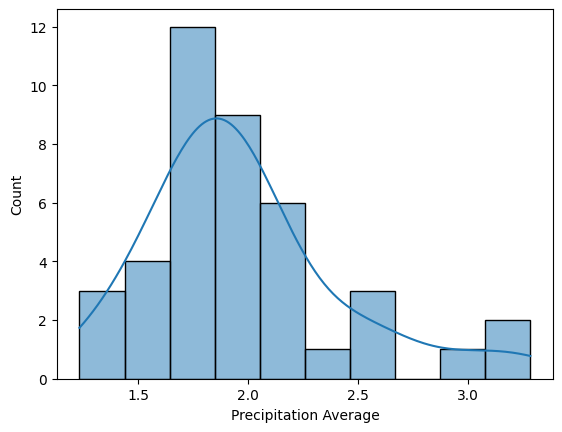

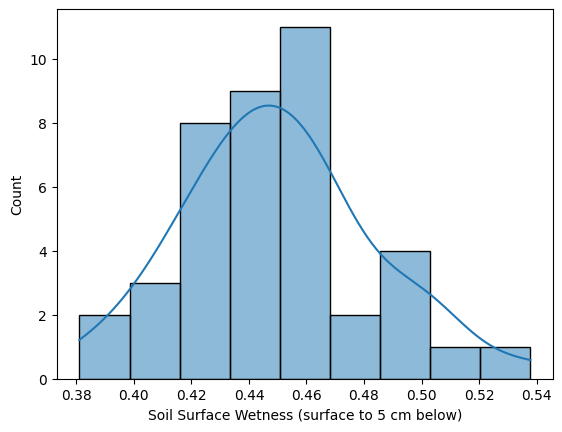

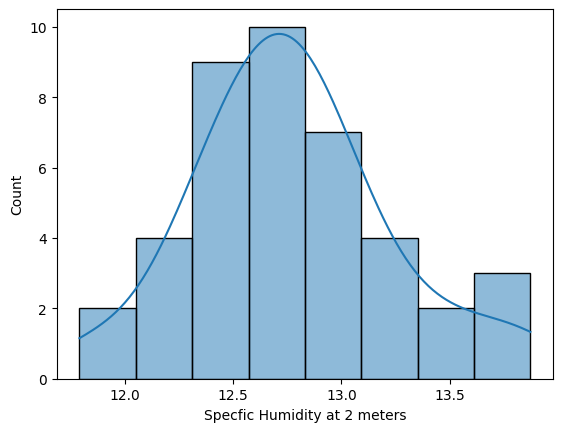

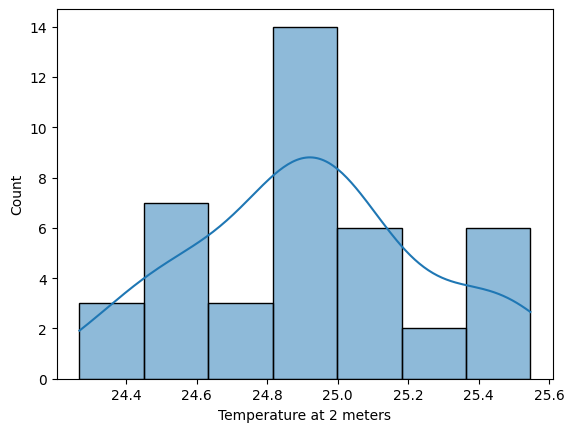

In [513]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(four_feats[col], kde = True)
    plt.show()

In [514]:
yield_data['Item'].value_counts()

Item
Beans, dry       41
Coffee, green    41
Maize (corn)     41
Tea leaves       41
Wheat            41
Name: count, dtype: int64

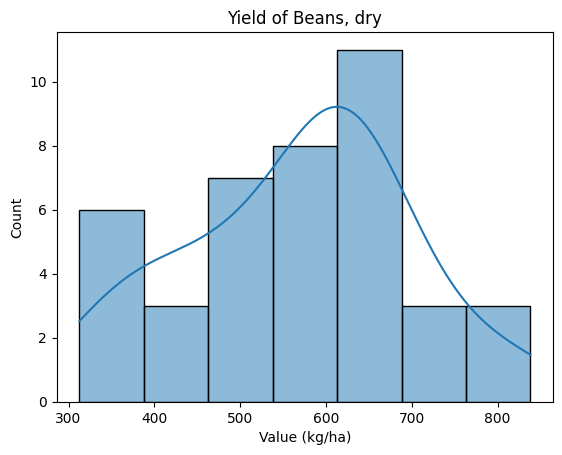

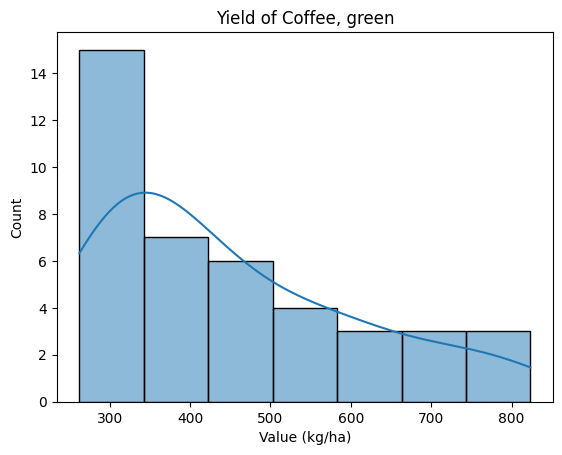

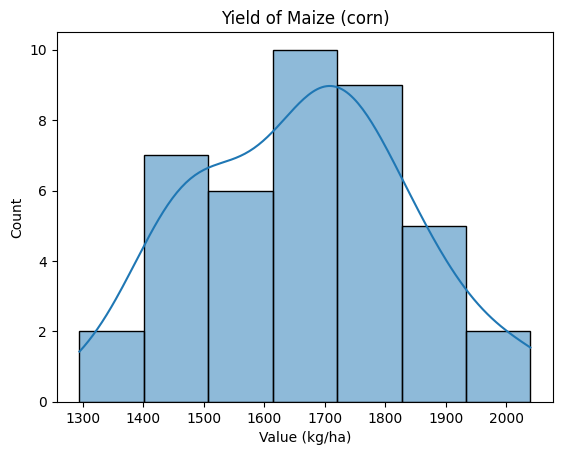

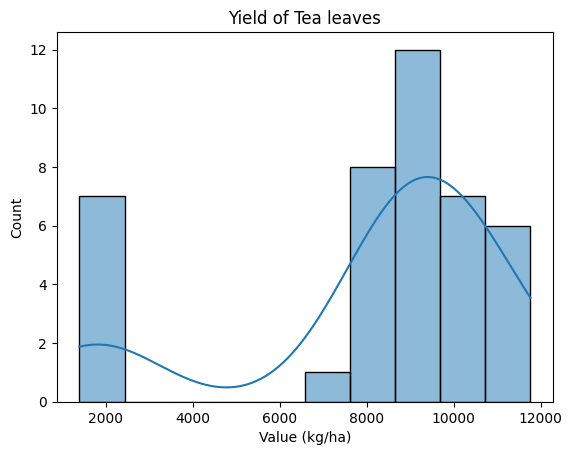

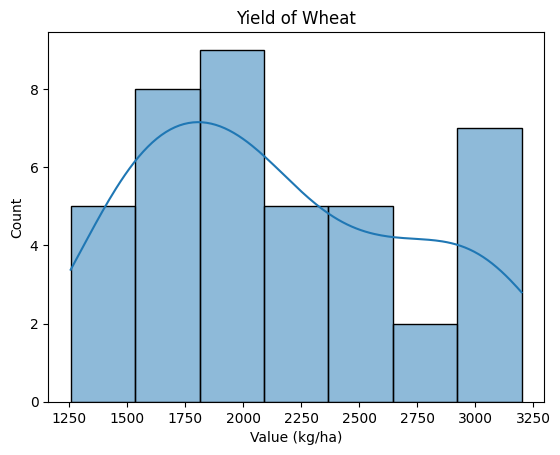

In [515]:
food_type = ['Beans, dry','Coffee, green','Maize (corn)','Tea leaves','Wheat']
for food in food_type: 
    filtered_df = yield_data[yield_data['Item'] == food]
    plt.figure()
    sns.histplot(filtered_df['Value (kg/ha)'], kde = True)
    plt.title(f'Yield of {food}')
    plt.show()

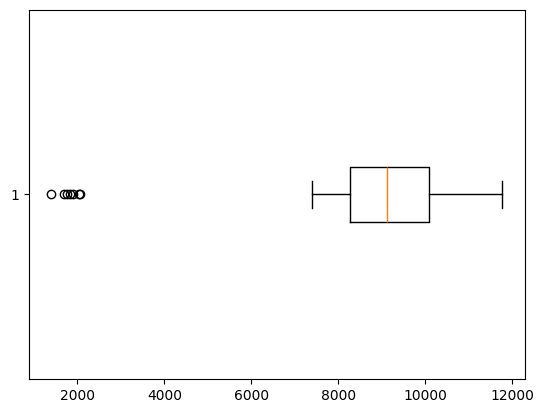

In [516]:
#filtered_yield = yield_data[yield_data['Item'] == 'Tea leaves']
plt.boxplot(yield_data[yield_data['Item'] == 'Tea leaves']['Value (kg/ha)'], vert = False)
plt.show()

In [517]:
Q1 = yield_data[yield_data['Item'] == 'Tea leaves']['Value (kg/ha)'].quantile(0.25)
Q3 = yield_data[yield_data['Item'] == 'Tea leaves']['Value (kg/ha)'].quantile(0.75)

IQR = Q3 - Q1

In [518]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_data[yield_data['Item'] == 'Tea leaves'] = yield_data[yield_data['Item'] == 
                                'Tea leaves'][(yield_data[yield_data['Item'] == 'Tea leaves']['Value (kg/ha)'] >= lower_bound) 
                                & (yield_data[yield_data['Item'] == 'Tea leaves']['Value (kg/ha)'] <= upper_bound)]

In [519]:
yield_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 205 entries, 1984-01-01 to 2024-01-01
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Item           198 non-null    str    
 1   Value (kg/ha)  198 non-null    float64
dtypes: float64(1), str(1)
memory usage: 4.8 KB


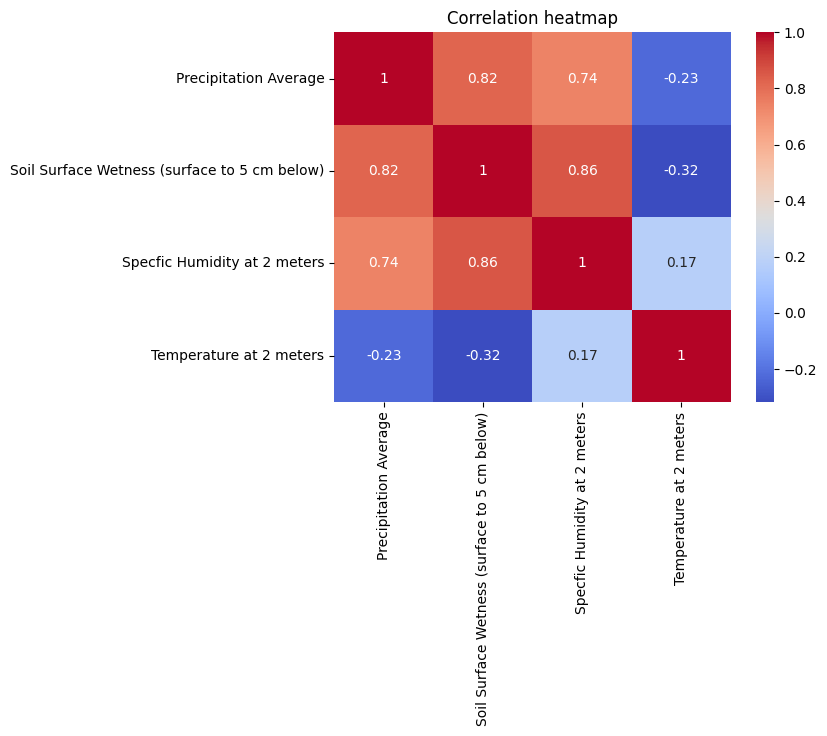

In [520]:
sns.heatmap(four_feats.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title('Correlation heatmap')
plt.show()